# Restaurant Revenue Prediction

**Author:** Nour Eldin Islam

**Dataset:** https://www.kaggle.com/datasets/mrsimple07/restaurants-revenue-prediction/data

## Objective

Predict a restaurant's monthly revenue from its business characteristics using supervised machine learning.

**Workflow followed:**
1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training
5. Model Evaluation & Comparison
6. Interpretation & Business Insights

## 1. Imports

In [ ]:
from statistics import linear_regression

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 2. Load Dataset

In [ ]:
df = pd.read_csv("Restaurant_revenue .csv")

df.head()

## 3. Dataset Overview

Before any analysis, we check the shape, data types, and summary statistics to understand what we're working with.

In [ ]:
df.shape

In [ ]:
df.dtypes

In [ ]:
df.describe()

### Feature Descriptions

| Feature | Data Type | Description |
|---------|-----------|-------------|
| Number_of_Customers | Integer | Number of customers visiting the restaurant. |
| Menu_Price | Float | Average price of items on the restaurant's menu. |
| Marketing_Spend | Float | Amount spent on marketing and advertising. |
| Cuisine_Type | Categorical | Type of cuisine served (Italian, Japanese, Mexican, American). |
| Average_Customer_Spending | Float | Average amount spent by each customer. |
| Promotions | Integer (0/1) | Whether a promotion or discount was active. |
| Reviews | Integer | Customer review score/count. |
| Monthly_Revenue | Float | **Target variable** — the restaurant's monthly revenue. |

## 4. Data Quality Checks

Checking for missing values and duplicate rows before doing any analysis, since both would distort our statistics and models if left unnoticed.

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

**Result:** no missing values and no duplicate rows. The dataset is structurally clean — any issues we find from here on will be about the *values themselves*, not completeness.

## 5. Exploratory Data Analysis (EDA)

The goal of EDA is to answer three questions before modeling:
1. Is the target well-behaved (shape, outliers, impossible values)?
2. Which features actually relate to the target, and how?
3. Are there data quality problems that preprocessing needs to address?

### 5.1 Distribution of Monthly Revenue

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Monthly_Revenue"], bins=30, edgecolor="black")
axes[0].set_title("Distribution of Monthly Revenue")
axes[0].set_xlabel("Monthly Revenue")
axes[0].set_ylabel("Number of Restaurants")

axes[1].boxplot(df["Monthly_Revenue"])
axes[1].set_title("Boxplot of Monthly Revenue")

plt.tight_layout()
plt.show()

**Interpretation:** the distribution is approximately symmetric and bell-shaped, centered around 250-300. Skewness is close to 0, so no transformation (e.g. log) is needed for the target.

The boxplot shows a small cluster of points below the lower whisker — these are investigated next.

In [ ]:
df[df["Monthly_Revenue"] <= 0]

**Interpretation:** 5 rows have negative Monthly_Revenue, and all 5 have very few customers (10-17, near the minimum of the dataset). Since revenue being negative is not logically meaningful for this target, these are treated as noise/impossible values and will be removed in preprocessing.

### 5.2 Numeric Features vs Monthly Revenue

In [ ]:
num_features = ["Number_of_Customers", "Menu_Price", "Marketing_Spend",
                "Average_Customer_Spending", "Reviews"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df["Monthly_Revenue"], alpha=0.4, s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Monthly_Revenue")
    axes[i].set_title(f"{col} vs Revenue")

axes[5].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:**
- `Number_of_Customers` has a strong, clearly linear relationship with revenue (correlation ≈ 0.75) — the dominant driver.
- `Menu_Price` and `Marketing_Spend` show weaker but real positive trends (correlation ≈ 0.26-0.27).
- `Average_Customer_Spending` and `Reviews` show flat, shapeless scatter plots and near-zero correlation (~ -0.02 to -0.04) — no detectable relationship, linear or otherwise.

### 5.3 Cuisine Type vs Revenue

A bar chart of group averages can be misleading on its own — some category will always look "highest," even if the difference is just noise. A one-way ANOVA test checks whether the differences between group means are larger than what random chance alone would produce.

In [ ]:
avg_revenue = df.groupby("Cuisine_Type")["Monthly_Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(avg_revenue.index, avg_revenue.values)
plt.title("Average Monthly Revenue by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Monthly Revenue")
plt.show()

print(avg_revenue)

In [ ]:
groups = [g["Monthly_Revenue"].values for _, g in df.groupby("Cuisine_Type")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat, " p-value:", p_value)

**Interpretation:** the bar chart alone suggests Japanese restaurants earn the most and Italian the least, but the gap (~8) is tiny relative to the overall spread of revenue (std ≈ 104). The ANOVA test confirms this: p-value ≈ 0.85, far above the 0.05 significance threshold. **Cuisine_Type has no statistically significant effect on revenue** — the bar chart differences are just noise. This feature will be dropped in preprocessing.

### 5.4 Promotions vs Revenue

Same logic as above, but for two groups instead of four, we use a t-test instead of ANOVA (the t-test is the two-group special case of ANOVA).

In [ ]:
df.boxplot(column="Monthly_Revenue", by="Promotions")
plt.title("Revenue by Promotions")
plt.suptitle("")
plt.xlabel("Promotions (0 = No, 1 = Yes)")
plt.ylabel("Monthly Revenue")
plt.show()

t_stat, p_value = stats.ttest_ind(
    df[df.Promotions == 1]["Monthly_Revenue"],
    df[df.Promotions == 0]["Monthly_Revenue"]
)
print("t-statistic:", t_stat, " p-value:", p_value)

**Interpretation:** mean revenue is nearly identical with vs without promotions (270.3 vs 267.2), and the t-test gives p ≈ 0.64 — not significant. Promotions do not show a detectable effect on revenue in this dataset.

### EDA Summary

| Finding | Decision for Preprocessing |
|---|---|
| Target is symmetric, no skew | No transformation needed |
| 5 rows have negative revenue (all very few customers) | **Drop these rows** |
| `Number_of_Customers`, `Menu_Price`, `Marketing_Spend` are real predictors | Keep |
| `Reviews`, `Average_Customer_Spending` show no relationship | Keep for now — will build a model with vs without these to test empirically |
| `Cuisine_Type` — no significant effect (ANOVA p=0.85) | **Drop this column** |
| `Promotions` — no significant effect (t-test p=0.64) | Keep for now — included in the "with weak features" comparison model |
| No missing values, no duplicates | Nothing to clean here |

## 6. Data Preprocessing

Based on the EDA findings above, we apply two changes before modeling:
1. Drop the 5 rows with negative `Monthly_Revenue` (impossible values).
2. Drop the `Cuisine_Type` column (no significant relationship with the target, confirmed by ANOVA).

In [ ]:
df = df[df["Monthly_Revenue"] > 0]
df = df.drop(columns=["Cuisine_Type"])

df.head()

In [ ]:
df.shape

**Check:** shape should now be (995, 7) — 5 rows removed, 1 column removed. All remaining columns are numeric, so no further encoding is required.

## 7. Ready for Modeling

The dataset is now clean and fully numeric. Next steps: train/test split, then train two Linear Regression models —
- **Model A:** all remaining features (including the "weak" ones: `Average_Customer_Spending`, `Promotions`, `Reviews`)
- **Model B:** only the strong features (`Number_of_Customers`, `Menu_Price`, `Marketing_Spend`)

...and compare their performance on the same test set.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Model A: Training with All Remaining Features

We separate the predictors (`X`) from the target (`Y`) and split the data into training and testing sets. The model learns from 80% of the observations and is evaluated on the remaining 20%, which were not used during training.

Using `random_state=42` makes the split reproducible, so the same observations are selected each time the notebook is run.


In [33]:
X = df[["Number_of_Customers", "Menu_Price", "Marketing_Spend", "Average_Customer_Spending", "Reviews", "Promotions"]]
Y = df["Monthly_Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model A: Evaluation

We evaluate predictions using three complementary metrics. **R²** measures how much of the variation in revenue is explained by the model. **MAE** represents the average absolute prediction error, while **RMSE** gives greater weight to larger errors.

Together, these metrics help us judge both the overall explanatory power and the typical size of prediction errors.

In [34]:
y_pred_A = model.predict(X_test)

r2 = r2_score(y_test, y_pred_A)
mae = mean_absolute_error(y_test, y_pred_A)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_A))

print("--- Model Accuracy Metrics ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

--- Model Accuracy Metrics ---
R-squared (R²): 0.6504
Mean Absolute Error (MAE): $46.92
Root Mean Squared Error (RMSE): $59.76


### Model B: Using the Strongest Predictors

For the second model, we keep only the three numeric features identified during EDA as the strongest practical predictors: `Number_of_Customers`, `Menu_Price`, and `Marketing_Spend`. This lets us compare a broader model with a simpler model and see whether the weaker variables add useful predictive information.



In [35]:
X = df[["Number_of_Customers", "Menu_Price", "Marketing_Spend"]]
Y = df["Monthly_Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model B: Evaluation

We calculate the same R², MAE, and RMSE metrics so that Model B can be compared fairly with Model A. A simpler model is useful if it achieves similar predictive performance while requiring fewer inputs.


In [36]:
y_pred_B = model.predict(X_test)

r2 = r2_score(y_test, y_pred_B)
mae = mean_absolute_error(y_test, y_pred_B)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_B))

print("--- Model Accuracy Metrics ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

--- Model Accuracy Metrics ---
R-squared (R²): 0.6545
Mean Absolute Error (MAE): $46.53
Root Mean Squared Error (RMSE): $59.41


Comparison

Model B performs slightly better than Model A across all three evaluation metrics.

The R² increased from 0.6504 to 0.6545, meaning Model B explains slightly more of the variation in monthly revenue.
The MAE decreased from $46.92 to $46.53, meaning Model B's predictions are slightly closer to the actual revenue on average.
The RMSE decreased from $59.76 to $59.41, showing that Model B also has slightly lower overall prediction error.

Although the improvement is small, Model B has an important advantage: it achieves better performance using only three features instead of six. This makes the model simpler and easier to interpret without sacrificing predictive ability.

Final Decision

Based on both the exploratory analysis and model evaluation, Model B is the preferred model for this project.

The results suggest that customer volume, menu pricing, and marketing spending contain most of the useful predictive information for estimating monthly restaurant revenue in this dataset. The final R² of approximately 0.65 indicates that the model explains around 65% of the variation in monthly revenue, while the remaining variation may be caused by factors that are not included in the dataset.

Therefore, the analysis demonstrates that careful feature selection can produce a simpler model with slightly better predictive performance. Further improvements could be achieved by adding variables such as location, seasonality, holidays, competition, operating costs, and customer behavior.

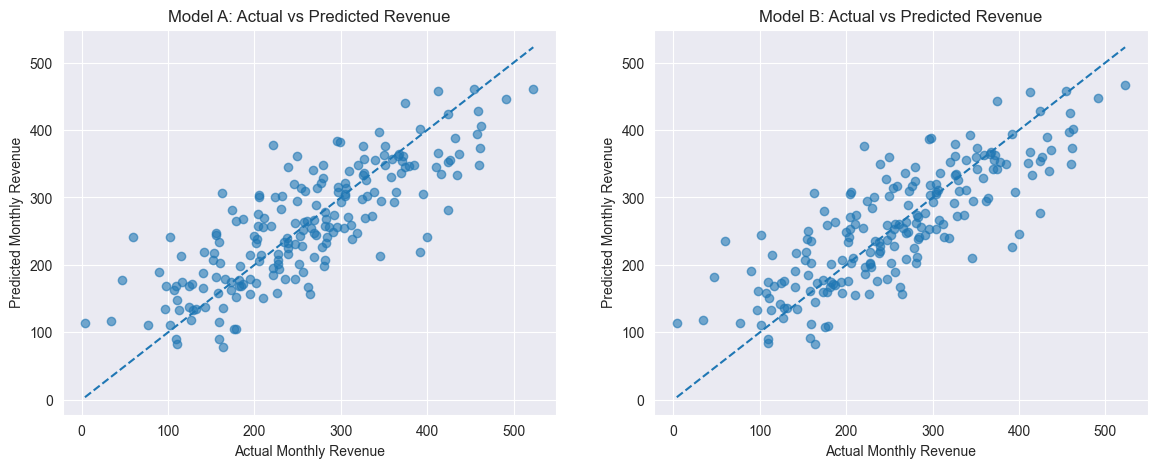

In [40]:
# Actual vs Predicted Revenue: Model A vs Model B

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Model A
# -------------------------
axes[0].scatter(y_test, y_pred_A, alpha=0.6)

min_val = min(y_test.min(), y_pred_A.min())
max_val = max(y_test.max(), y_pred_A.max())

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

axes[0].set_title("Model A: Actual vs Predicted Revenue")
axes[0].set_xlabel("Actual Monthly Revenue")
axes[0].set_ylabel("Predicted Monthly Revenue")


# -------------------------
# Model B
# -------------------------
axes[1].scatter(y_test, y_pred_B, alpha=0.6)

min_val = min(y_test.min(), y_pred_B.min())
max_val = max(y_test.max(), y_pred_B.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

axes[1].set_title("Model B: Actual vs Predicted Revenue")
axes[1].set_xlabel("Actual Monthly Revenue")
axes[1].set_ylabel("Predicted Monthly Revenue")



plt.show()